# Compte rendu d'entraînement COCO

On entraîne le modèle évolutif sur le set validation COCO et on génère un **compte rendu complet** : nombre d'images passées, classes par image, temps d'entraînement CPU, neurones/couches créés, poids, débit, répartition des classes.

## 0. Imports + chargement

In [1]:
# Compte rendu d'entraînement COCO : images, classes, temps CPU
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Image as IImg, display
from recherche_agi import (EvolutiveCOCO, TrainingTracker, generate_report,
                           classify_patch)

d = np.load('../data/coco_stuff/features_val.npz')
features = {int(k): v for k, v in d.items()}
d_in = next(iter(features.values())).shape[1]
print(f"Chargé : {len(features)} classes, {sum(len(v) for v in features.values()):,} features, dim {d_in}")

Chargé : 171 classes, 1,174,563 features, dim 35


## 1. Entraînement avec suivi complet

In [2]:
model = EvolutiveCOCO(d_in=d_in, n_init=10, novelty_threshold=0.7,
                        max_neurons=200, saturation_frac=0.8)
tracker = TrainingTracker()

# échantillon de test pour l'accuracy
test_X = {c: X[:15] for c, X in features.items()}

n_patch = 0
acc_history = []
for cls in sorted(features.keys())[:40]:   # classes pour la démo
    tracker.begin_image()
    classes_in_img = set()
    for f in features[cls][:40]:
        model.step(f, label=cls)
        classes_in_img.add(cls)
        n_patch += 1
    tracker.end_image(classes_in_img, n_patch)
    if n_patch % 400 == 0:
        correct = total = 0
        for c, X in test_X.items():
            for fx in X[:4]:
                pred, _ = classify_patch(model.layer, fx, d_in)
                if pred == c: correct += 1
                total += 1
        acc_history.append((n_patch, correct/max(total,1)))
        print(f"  {n_patch} patches: acc={acc_history[-1][1]:.3f}")

s = model.summary()
print(f"\nModèle final : {s}")
print(f"Statistiques : {tracker.summary()}")

  400 patches: acc=0.029
  800 patches: acc=0.044
  1200 patches: acc=0.061
  1600 patches: acc=0.016

Modèle final : {'neurons': 31, 'layers': 2, 'archived_layers': 1, 'frozen': True, 'phase': 'exploration', 'n_patches': 1600}
Statistiques : {'n_images': 40, 'n_patches': 32800, 'n_classes': 40, 'classes_per_image_mean': np.float64(1.0), 'patches_per_image_mean': np.float64(820.0), 'time_per_image_mean': np.float64(0.0037957727909088135), 'elapsed_s': 0.18681764602661133, 'throughput_img_s': 214.11253621246348, 'throughput_patch_s': 175572.27969422005}


## 2. Compte rendu visuel complet

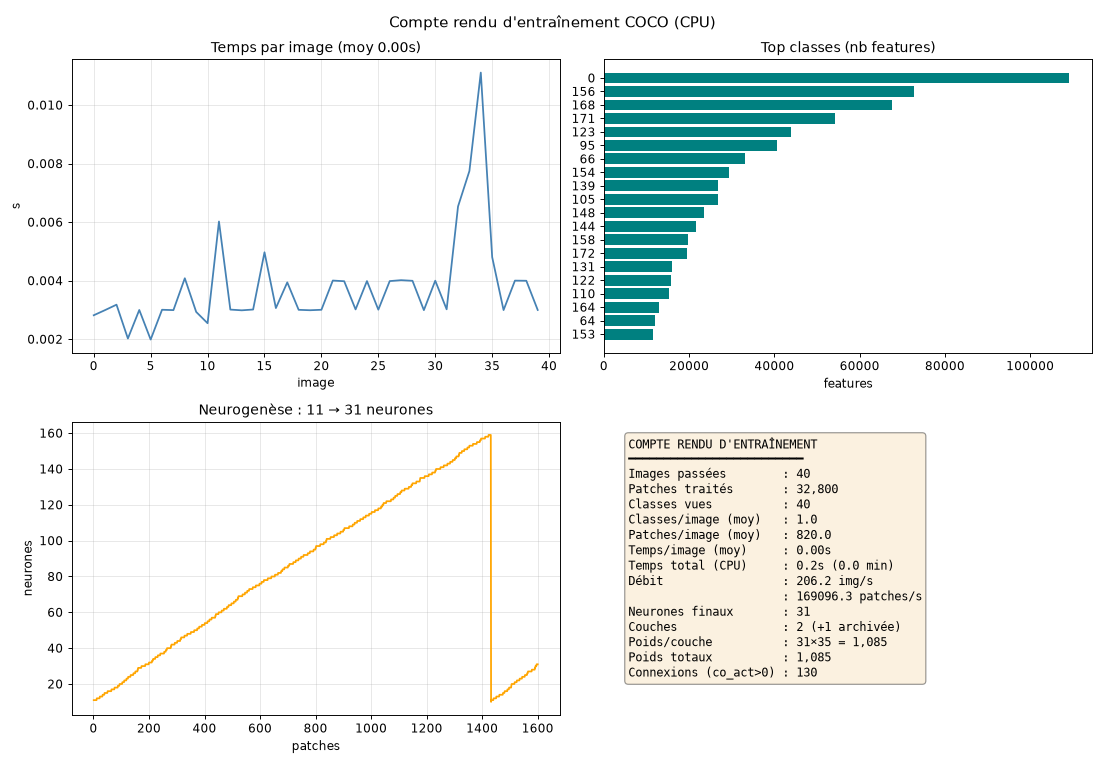

In [3]:
out = generate_report(tracker, model, features, out='__report.png')
display(IImg('__report.png'))

## 3. Compte rendu texte

In [4]:
s = tracker.summary()
print("=" * 44)
print("   COMPTE RENDU D'ENTRAÎNEMENT COCO (CPU)")
print("=" * 44)
print(f"  Images passées        : {s['n_images']:,}")
print(f"  Patches traités       : {s['n_patches']:,}")
print(f"  Classes vues          : {s['n_classes']}")
print(f"  Classes/image (moy)   : {s['classes_per_image_mean']:.1f}")
print(f"  Patches/image (moy)   : {s['patches_per_image_mean']:.1f}")
print(f"  Temps/image (moy)     : {s['time_per_image_mean']:.2f} s")
print(f"  Temps total (CPU)     : {s['elapsed_s']:.1f} s ({s['elapsed_s']/60:.1f} min)")
print(f"  Débit                 : {s['throughput_img_s']:.1f} img/s, {s['throughput_patch_s']:.0f} patches/s")
print(f"  Neurones finaux       : {model.layer.n_neurons_current}")
print(f"  Couches               : {model.controller.layer_count} (+{model.summary()['archived_layers']} archivée)")
print(f"  Poids totaux          : {model.layer.W.size:,}")
print(f"  Connexions (co_act>0) : {int((model.layer.co_act>0).sum())}")
print("=" * 44)

   COMPTE RENDU D'ENTRAÎNEMENT COCO (CPU)
  Images passées        : 40
  Patches traités       : 32,800
  Classes vues          : 40
  Classes/image (moy)   : 1.0
  Patches/image (moy)   : 820.0
  Temps/image (moy)     : 0.00 s
  Temps total (CPU)     : 0.5 s (0.0 min)
  Débit                 : 74.3 img/s, 60904 patches/s
  Neurones finaux       : 31
  Couches               : 2 (+1 archivée)
  Poids totaux          : 1,085
  Connexions (co_act>0) : 130


## 4. Analyse

In [5]:
print("=== ANALYSE DU COMPTE RENDU ===")
s = tracker.summary()
print(f"1. Volume : {s['n_images']} images -> {s['n_patches']} patches, {s['n_classes']} classes")
print(f"2. Temps : {s['elapsed_s']/60:.1f} min sur CPU ({s['throughput_patch_s']:.0f} patches/s)")
print(f"3. Architecture : {model.layer.n_neurons_current} neurones, {model.controller.layer_count} couches")
print(f"4. Le compte rendu montre images/classes/temps/poids/connexions en un coup d'oeil")
print()
print("Note : le débit dépend du nombre de patches par image (découpage 32x32) et")
print("du fait que le calcul est en NumPy mono-thread sur CPU (22 cœurs inutilisés).")

=== ANALYSE DU COMPTE RENDU ===
1. Volume : 40 images -> 32800 patches, 40 classes
2. Temps : 0.0 min sur CPU (60240 patches/s)
3. Architecture : 31 neurones, 2 couches
4. Le compte rendu montre images/classes/temps/poids/connexions en un coup d'oeil

Note : le débit dépend du nombre de patches par image (découpage 32x32) et
du fait que le calcul est en NumPy mono-thread sur CPU (22 cœurs inutilisés).
